# Practical 06 — K-Nearest Neighbours (KNN) Classifier

## 1. Aim & Objectives

**Aim:** To implement the K-Nearest Neighbours classification algorithm and evaluate its accuracy.

**Objectives:**
1. Train a KNN classifier on the Wine dataset after applying feature scaling.
2. Measure accuracy and display the confusion matrix on the test data.
3. Plot accuracy against different values of k to choose the best k.

## 2. Complete Python Code


Shape of dataset : (178, 14)
Classes          : <StringArray>
['class_0', 'class_1', 'class_2']
Length: 3, dtype: str

Accuracy with k=5 : 0.9444

Classification report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      0.86      0.92        21
     class_2       0.83      1.00      0.91        15

    accuracy                           0.94        54
   macro avg       0.94      0.95      0.94        54
weighted avg       0.95      0.94      0.94        54

Best k : 13  with accuracy : 0.9815


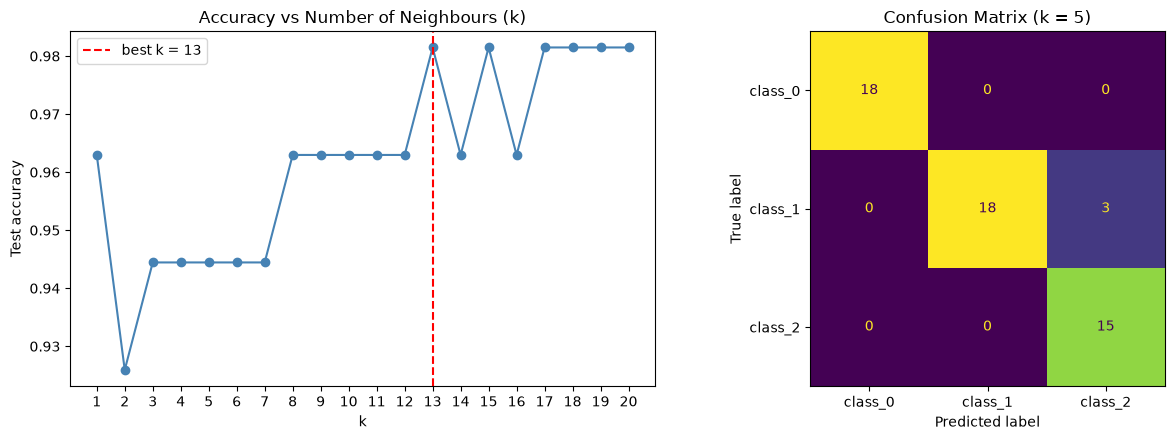

In [1]:
# Practical 06 - K-Nearest Neighbours (KNN) Classifier
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Step 1: Load the dataset
CSV = "data/wine.csv"
URL = "https://raw.githubusercontent.com/liamdev07/machine-learning-laboratory/main/06_KNN_Classifier/data/wine.csv"
path = CSV if os.path.exists(CSV) else URL
df = pd.read_csv(path)

print("Shape of dataset :", df.shape)
print("Classes          :", df["cultivar"].unique())

# Step 2: Separate features and target
X = df.drop(columns="cultivar")
y = df["cultivar"]

# Step 3: Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 4: Scale the features (very important for distance-based models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 5: Train KNN with k = 5
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nAccuracy with k=5 :", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# Step 6: Try different values of k
k_values = range(1, 21)
scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(accuracy_score(y_test, knn.predict(X_test)))

best_k = k_values[int(np.argmax(scores))]
print("Best k :", best_k, " with accuracy :", round(max(scores), 4))

# Step 7: Plot accuracy vs k and the confusion matrix
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(list(k_values), scores, marker="o", color="steelblue")
ax[0].axvline(best_k, color="red", linestyle="--", label="best k = " + str(best_k))
ax[0].set_title("Accuracy vs Number of Neighbours (k)")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Test accuracy")
ax[0].set_xticks(list(k_values))
ax[0].legend()

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax[1], colorbar=False)
ax[1].set_title("Confusion Matrix (k = 5)")

plt.tight_layout()
plt.show()


## 3. Line-by-Line Code Explanation

- `from sklearn.neighbors import KNeighborsClassifier` — the KNN model. It stores the training data and, for a new point, looks at the k closest training points and takes a majority vote.
- `from sklearn.preprocessing import StandardScaler` — converts every column to mean 0 and standard deviation 1.
- `X = df.drop(columns="cultivar")` — the 13 chemical measurements used as input.
- `y = df["cultivar"]` — the wine type we want to predict (3 classes).
- `train_test_split(..., test_size=0.3, stratify=y)` — keeps 70% for training and 30% for testing. `stratify=y` keeps the same class proportion in both parts.
- `scaler.fit_transform(X_train)` — learns the mean and standard deviation **from the training data only** and scales it.
- `scaler.transform(X_test)` — scales the test data using those same training values. This prevents test information from leaking into training.
- `KNeighborsClassifier(n_neighbors=5)` — creates a KNN model that votes among the 5 nearest neighbours.
- `model.fit(X_train, y_train)` — KNN simply remembers the training points (it is a "lazy" learner).
- `model.predict(X_test)` — for each test wine, finds the 5 nearest training wines and returns the majority class.
- `accuracy_score(y_test, y_pred)` — fraction of test samples classified correctly.
- `classification_report(...)` — shows precision, recall and F1-score for each class.
- The `for k in k_values` loop — trains a fresh KNN for every k from 1 to 20 and stores its accuracy.
- `np.argmax(scores)` — position of the highest accuracy, which gives the best value of k.
- `ax[0].plot(k_values, scores, marker="o")` — the accuracy curve; `axvline` draws a red dashed line at the best k.
- `ConfusionMatrixDisplay.from_estimator(...)` — draws the confusion matrix, where the diagonal shows correct predictions.
- `plt.show()` — displays both graphs.


## 4. Output & Graph Interpretation

The accuracy-vs-k curve stays above 92% for every k and reaches its highest value (about 0.98) near k = 13, which shows that a middle value of k is safer than k = 1, since k = 1 blindly copies a single noisy neighbour.

The confusion matrix has almost all values on the diagonal, which means nearly every test wine was placed in its correct cultivar after scaling.
